In [1]:
import pandas as pd
import re
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from currency_converter import CurrencyConverter
import cpi
from datetime import date

In [2]:
# load in relevant files
df = pd.read_csv('data/final_dataset.csv')
keyw = pd.read_csv('data/keywords.csv')
mm = pd.read_csv("data/movies_metadata.csv")

C:\Users\hartl\AppData\Local\Temp\ipykernel_23016\1206468364.py:4: DtypeWarning: Columns (0: popularity) have mixed types. Specify dtype option on import or set low_memory=False.
  mm = pd.read_csv("data/movies_metadata.csv")


In [3]:
# this has the movies metadata
https://www.kaggle.com/datasets/raedaddala/top-500-600-movies-of-each-year-from-1960-to-2024
# it is an aggregated version of this dataset
https://www.kaggle.com/datasets/raedaddala/imdb-movies-from-1960-to-2023

# this has the keywords
https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset/data

SyntaxError: invalid syntax (768647171.py, line 2)

In [4]:
mm_id_key = mm[['id', 'imdb_id']]

In [5]:
def list_dict(x):
    empt = []
    for di in x:
        empt.append(di['name'])
    return empt

In [6]:
# convert the keywords from string dictionaries to lists of just keywords
keyw['keywords'] = keyw['keywords'].apply(lambda x: eval(x))
keyw['keywords'] = keyw['keywords'].apply(lambda x: list_dict(x))

In [7]:
# drop the couple of movies with no IMDB id in the dataset
mm_id_key = mm_id_key[mm_id_key['imdb_id'] != '0']
mm_id_key['id'] = pd.to_numeric(mm_id_key['id'], downcast='integer')

# merge the keywords with the primary movies dataset
key_id = keyw.merge(mm_id_key, on='id', how='inner')
key_id = key_id[['imdb_id', 'keywords']]

In [8]:
full_movies = df.merge(key_id, left_on='id', right_on='imdb_id', how='left')
full_movies = full_movies.drop('imdb_id', axis=1)

In [9]:
full_movies

,id,title,duration,mpa,rating,votes,méta_score,description,movie_link,writers,...,gross_worldwide,gross_us_canada,release_date,countries_origin,filming_locations,production_companies,awards_content,genres,languages,keywords
0,tt0027483,The Crimson Circle,1h 16m,NaN,6.4,30,NaN,An extortion ring murders anyone who refuses t...,https://www.imdb.com/title/tt0027483/,"['Reginald Denham', 'Edgar Wallace', 'Howard I...",...,NaN,NaN,1936-08-10,['United Kingdom'],NaN,['Richard Wainwright Productions'],NaN,['Drama'],['English'],NaN
1,tt0058131,The Mystery of Thug Island,1h 36m,NaN,5.0,114,NaN,"Three year old Ada, daughter of the British ca...",https://www.imdb.com/title/tt0058131/,"['Emilio Salgari', 'Arpad DeRiso', 'Ottavio Po...",...,NaN,NaN,1966-05-28,"['Italy', 'Monaco', 'West Germany']",NaN,"['Eichberg-Film', 'Liber Film']",NaN,['Adventure'],['Italian'],NaN
2,tt0042760,Las mujeres de mi general,1h 52m,Not Rated,6.8,74,NaN,Infante stars as a rebel general caught up in ...,https://www.imdb.com/title/tt0042760/,"['Joselito Rodríguez', 'Celestino Gorostiza', ...",...,NaN,NaN,1951-07-13,['Mexico'],NaN,['Producciones Rodríguez Hermanos'],NaN,"['Drama', 'War']",['Spanish'],NaN
3,tt0027667,Gentle Julia,1h 2m,Approved,6.8,38,NaN,A shy newspaperman (Brown) nearly gives up whe...,https://www.imdb.com/title/tt0027667/,"['Booth Tarkington', 'Lamar Trotti']",...,NaN,NaN,1936-04-10,['United States'],"['20th Century Fox Studios - 10201 Pico Blvd.,...",['Twentieth Century Fox'],NaN,"['Comedy', 'Drama', 'Romance']",['English'],NaN
4,tt0055747,Love at Twenty,1h 50m,NaN,7.2,2.5K,NaN,"""Love at Twenty"" unites five directors from ar...",https://www.imdb.com/title/tt0055747/,"['Shintarô Ishihara', 'Marcel Ophüls', 'Renzo ...",...,NaN,NaN,1963-02-06,"['France', 'Italy', 'Japan', 'Poland', 'West G...","['Warsaw Zoo, Ratuszowa, Praga Pólnoc, Warsaw,...","['Ulysse Productions', 'Unitec Films', 'Cinese...",NaN,"['Drama', 'Romance']","['French', 'Polish', 'Japanese', 'Italian', 'G...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63658,tt0160310,Girl with an Itch,1h 17m,Approved,6.4,63,NaN,"A lonely, widowed middle-aged ranch owner give...",https://www.imdb.com/title/tt0160310/,"['Ralph S. Whiting', 'Peter Perry Jr.', 'E. Sh...",...,NaN,NaN,1958-11-12,['United States'],"['Los Angeles County, California, USA']",['The Don-Tru Company'],NaN,['Drama'],['English'],NaN
63659,tt0103069,Texasville,2h 6m,R,6.0,3.2K,49.0,The summer of 1984: 32 years after Duane Jacks...,https://www.imdb.com/title/tt0103069/,"['Larry McMurtry', 'Peter Bogdanovich']",...,"$2,268,181","$2,268,181",1990-09-28,['United States'],"['Archer City, Texas, USA']","['Cine-Source', 'Nelson Entertainment']",NaN,"['Drama', 'Romance']",['English'],"[texas, high school sweetheart]"
63660,tt1473380,Kalai Arasi,2h 3m,NaN,8.0,56,NaN,Vani is kidnapped by aliens who need her to te...,https://www.imdb.com/title/tt1473380/,['T.E. Gnanamurthy'],...,NaN,NaN,1963-04-19,['India'],NaN,['Sarodi Brothers'],NaN,"['Comedy', 'Fantasy']",['Tamil'],NaN
63661,tt0247184,Aprili,45m,NaN,7.2,522,NaN,A young happy couple moves from a poor distric...,https://www.imdb.com/title/tt0247184/,"['Erlom Akhvlediani', 'Otar Iosseliani']",...,NaN,NaN,1962-09-28,['Soviet Union'],NaN,"['Georgian-Film', 'Gruziya Film', 'Qartuli Pil...",NaN,"['Comedy', 'Drama', 'Romance']",['Georgian'],[]


In [10]:
# drop the columns without relevant predictors or multicollinear predictors
full_movies = full_movies.drop(['méta_score','description', 'movie_link', 'writers', 'directors', 'stars', 'budget',
       'opening_weekend_gross','countries_origin', 'filming_locations',
       'production_companies', 'awards_content'], axis=1)

In [11]:
full_movies.head()

,id,title,duration,mpa,rating,votes,gross_worldwide,gross_us_canada,release_date,genres,languages,keywords
0,tt0027483,The Crimson Circle,1h 16m,NaN,6.4,30,NaN,NaN,1936-08-10,['Drama'],['English'],NaN
1,tt0058131,The Mystery of Thug Island,1h 36m,NaN,5.0,114,NaN,NaN,1966-05-28,['Adventure'],['Italian'],NaN
2,tt0042760,Las mujeres de mi general,1h 52m,Not Rated,6.8,74,NaN,NaN,1951-07-13,"['Drama', 'War']",['Spanish'],NaN
3,tt0027667,Gentle Julia,1h 2m,Approved,6.8,38,NaN,NaN,1936-04-10,"['Comedy', 'Drama', 'Romance']",['English'],NaN
4,tt0055747,Love at Twenty,1h 50m,NaN,7.2,2.5K,NaN,NaN,1963-02-06,"['Drama', 'Romance']","['French', 'Polish', 'Japanese', 'Italian', 'G...",NaN


In [12]:
full_movies['eng_lang'] = full_movies['languages'].apply(lambda x: 1 if "English" in str(x) else 0)

In [13]:
full_movies.head()

,id,title,duration,mpa,rating,votes,gross_worldwide,gross_us_canada,release_date,genres,languages,keywords,eng_lang
0,tt0027483,The Crimson Circle,1h 16m,NaN,6.4,30,NaN,NaN,1936-08-10,['Drama'],['English'],NaN,1
1,tt0058131,The Mystery of Thug Island,1h 36m,NaN,5.0,114,NaN,NaN,1966-05-28,['Adventure'],['Italian'],NaN,0
2,tt0042760,Las mujeres de mi general,1h 52m,Not Rated,6.8,74,NaN,NaN,1951-07-13,"['Drama', 'War']",['Spanish'],NaN,0
3,tt0027667,Gentle Julia,1h 2m,Approved,6.8,38,NaN,NaN,1936-04-10,"['Comedy', 'Drama', 'Romance']",['English'],NaN,1
4,tt0055747,Love at Twenty,1h 50m,NaN,7.2,2.5K,NaN,NaN,1963-02-06,"['Drama', 'Romance']","['French', 'Polish', 'Japanese', 'Italian', 'G...",NaN,0


In [14]:
full_movies.describe()

,rating,eng_lang
count,59595.000000,63663.000000
mean,6.163205,0.675997
std,1.070316,0.468005
min,1.000000,0.000000
25%,5.500000,0.000000
50%,6.300000,1.000000
75%,6.900000,1.000000
max,10.000000,1.000000


In [15]:
full_movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 63663 entries, 0 to 63662
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               63663 non-null  str    
 1   title            63663 non-null  str    
 2   duration         61588 non-null  str    
 3   mpa              41553 non-null  str    
 4   rating           59595 non-null  float64
 5   votes            59595 non-null  str    
 6   gross_worldwide  20909 non-null  str    
 7   gross_us_canada  19735 non-null  str    
 8   release_date     63663 non-null  str    
 9   genres           62876 non-null  str    
 10  languages        63333 non-null  str    
 11  keywords         25673 non-null  object 
 12  eng_lang         63663 non-null  int64  
dtypes: float64(1), int64(1), object(1), str(10)
memory usage: 6.3+ MB


In [16]:
# type conversion helper functions
def parse_shorthand(s: str):
    if type(s) is str:
        s = s.strip().upper().replace(",", "")
        m = re.match(r"^([0-9]+(?:\.[0-9]+)?)\s*([KMGTB]?)$", s)
        if not m:
            raise ValueError(f"can't parse: {s}")
        value, suffix = m.groups()
        value = float(value)
        multipliers = {"": 1, "K": 10**3, "M": 10**6, "G": 10**9, "T": 10**12, "B": 10**9}
        return int(value * multipliers.get(suffix, 1))
    return s

def parse_monetary(s: str):
    if type(s) is str:
        s = re.sub(r'[^0-9]', '', s)
    return s

def parse_duration_to_minutes(s: str):
    if type(s) is str:
        s = s.strip().lower()
        pattern = r'^(?:(\d+(?:\.\d+)?)\s*(?:h|hr|hrs|hour|hours))?\s*(?:(\d+(?:\.\d+)?)\s*(?:m|min|mins|minute|minutes))?$'
        m = re.match(pattern, s)
        if not m or (not m.group(1) and not m.group(2)):
            return np.nan
        hours = float(m.group(1)) if m.group(1) else 0.0
        minutes = float(m.group(2)) if m.group(2) else 0.0
        return int(round(hours * 60 + minutes))
    return s

In [17]:
# some type conversions
full_movies['release_date'] = pd.to_datetime(full_movies['release_date'])
full_movies['votes'] = full_movies['votes'].apply(lambda x: parse_shorthand(x))

#full_movies['gross_worldwide'] = full_movies['gross_worldwide'].apply(lambda x: parse_monetary(x))
#full_movies['gross_worldwide'] = pd.to_numeric(full_movies['gross_worldwide'])

#full_movies['gross_us_canada'] = full_movies['gross_us_canada'].apply(lambda x: parse_monetary(x))
#full_movies['gross_us_canada'] = pd.to_numeric(full_movies['gross_us_canada'])

full_movies['duration'] = full_movies['duration'].apply(lambda x: parse_duration_to_minutes(x))

In [18]:
full_movies['languages'].value_counts()

languages
['English']                                    30310
['None', 'English']                             2278
['French']                                      2271
['Italian']                                     2210
['Spanish']                                     2079
                                               ...  
['English', 'Cantonese', 'Malay']                  1
['English', 'Burmese', 'Japanese']                 1
['Spanish', 'Hebrew']                              1
['Italian', 'English', 'Chinese', 'French']        1
['English', 'Japanese', 'Ukrainian']               1
Name: count, Length: 3255, dtype: int64

In [19]:
full_movies['genres'].value_counts()

genres
['Drama']                                                                                                                            7681
['Comedy']                                                                                                                           3512
['Drama', 'Romance']                                                                                                                 2582
['Comedy', 'Drama']                                                                                                                  1663
['Documentary']                                                                                                                      1331
                                                                                                                                     ... 
['Parody', 'Slapstick', 'Comedy', 'Mystery', 'Thriller']                                                                                1
['Parody', 'Satire', 'Comed

In [20]:
full_movies.describe()

,duration,rating,votes,release_date,eng_lang
count,61500.000000,59595.000000,5.959500e+04,63663,63663.000000
mean,95.850065,6.163205,1.814791e+04,1973-11-01 12:32:07.826209,0.675997
min,1.000000,1.000000,5.000000e+00,1920-01-01 00:00:00,0.000000
25%,82.000000,5.500000,1.650000e+02,1947-05-20 00:00:00,0.000000
50%,93.000000,6.300000,7.320000e+02,1974-04-22 00:00:00,1.000000
75%,105.000000,6.900000,4.400000e+03,2000-06-23 12:00:00,1.000000
max,5220.000000,10.000000,3.000000e+06,2026-07-10 00:00:00,1.000000
std,36.262583,1.070316,8.445379e+04,NaN,0.468005


In [21]:
full_movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 63663 entries, 0 to 63662
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               63663 non-null  str           
 1   title            63663 non-null  str           
 2   duration         61500 non-null  float64       
 3   mpa              41553 non-null  str           
 4   rating           59595 non-null  float64       
 5   votes            59595 non-null  float64       
 6   gross_worldwide  20909 non-null  str           
 7   gross_us_canada  19735 non-null  str           
 8   release_date     63663 non-null  datetime64[us]
 9   genres           62876 non-null  str           
 10  languages        63333 non-null  str           
 11  keywords         25673 non-null  object        
 12  eng_lang         63663 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(1), object(1), str(7)
memory usage: 6.3+ MB


In [22]:
full_movies.to_pickle("data/full_clean.pkl")

## EDA on cleaned data

Text(0.5, 1.0, 'Release dates of movies')

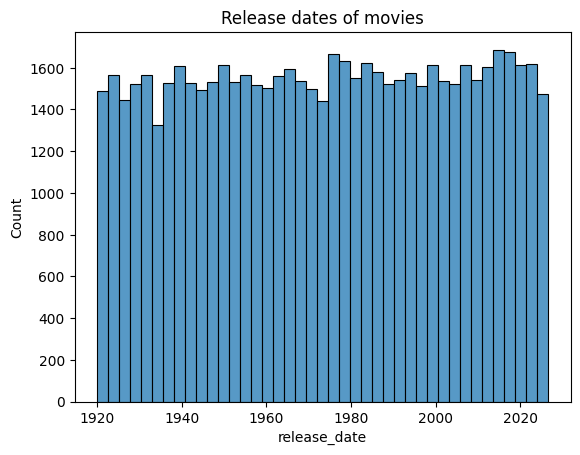

In [23]:
sns.histplot(full_movies['release_date'])
plt.title("Release dates of movies")

Text(0.5, 1.0, 'Ratings Distribution')

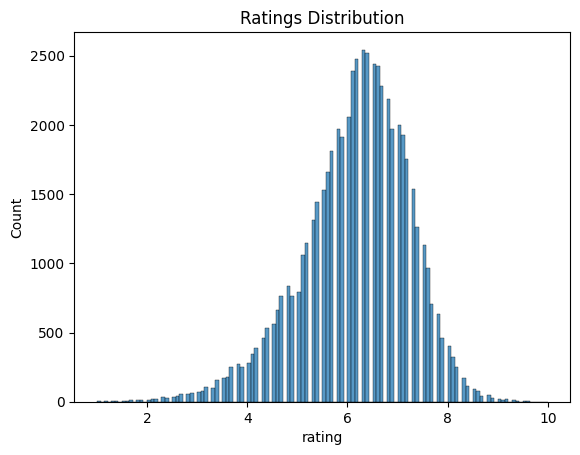

In [24]:
sns.histplot(full_movies['rating'])
plt.title('Ratings Distribution')

## Keyword Filtering

In [25]:
import pandas as pd
import numpy as np

df = pd.read_pickle('data/full_clean.pkl')
df.head()

,id,title,duration,mpa,rating,votes,gross_worldwide,gross_us_canada,release_date,genres,languages,keywords,eng_lang
0,tt0027483,The Crimson Circle,76.0,NaN,6.4,30.0,NaN,NaN,1936-08-10,['Drama'],['English'],NaN,1
1,tt0058131,The Mystery of Thug Island,96.0,NaN,5.0,114.0,NaN,NaN,1966-05-28,['Adventure'],['Italian'],NaN,0
2,tt0042760,Las mujeres de mi general,112.0,Not Rated,6.8,74.0,NaN,NaN,1951-07-13,"['Drama', 'War']",['Spanish'],NaN,0
3,tt0027667,Gentle Julia,62.0,Approved,6.8,38.0,NaN,NaN,1936-04-10,"['Comedy', 'Drama', 'Romance']",['English'],NaN,1
4,tt0055747,Love at Twenty,110.0,NaN,7.2,2500.0,NaN,NaN,1963-02-06,"['Drama', 'Romance']","['French', 'Polish', 'Japanese', 'Italian', 'G...",NaN,0


In [26]:
print(len(df))

63663


In [27]:
#explode keywords lists and make them lowercase, count the words
keyword_counts = df.explode('keywords')['keywords'].str.lower().value_counts()
#get the popular keywords by filtering on those that happen 100+ times
popular_keywords = set(keyword_counts[keyword_counts >= 100].index)

In [28]:
#filter the popular keywords in the keyword lists
def filter_popular(kw_list):
    #if it's not a list return as is
    if not isinstance(kw_list, list):
        return kw_list
    #keep only keywords that exist in the popular set
    return [kw for kw in kw_list if str(kw).lower() in popular_keywords]

#apply to the column
df['keywords'] = df['keywords'].apply(filter_popular)

In [29]:
df['keywords'].value_counts()

keywords
[]                                         11909
[woman director]                             764
[independent film]                           589
[musical]                                    344
[sport]                                      205
                                           ...  
[holiday, prison, drug]                        1
[female nudity, rape]                          1
[murder, independent film, zombie]             1
[sex, adultery, island, nudity, zombie]        1
[new york, daughter]                           1
Name: count, Length: 5410, dtype: int64

In [30]:
len(df)

63663

In [31]:
len(popular_keywords)

135

In [32]:
df.to_pickle('data/full_clean.pkl')

## Genre Feature Engineering


Here, We convert the multi-label genres column into machine-learning-ready features.

Rare genres are removed using a frequency threshold, and the remaining genres are one-hot encoded into binary indicator variables (genre_*).

These features will be used by downstream prediction models.

In [33]:
# look at raw genre structure
print(type(df.loc[0, "genres"]))
df["genres"].head(10)

<class 'str'>


0                             ['Drama']
1                         ['Adventure']
2                      ['Drama', 'War']
3        ['Comedy', 'Drama', 'Romance']
4                  ['Drama', 'Romance']
5    ['Dark Comedy', 'Comedy', 'Drama']
6                             ['Drama']
7                 ['Comedy', 'Mystery']
8                ['Biography', 'Drama']
9                      ['Drama', 'War']
Name: genres, dtype: str

In [34]:
# ensure every row is a list of strings
def clean_genres(x):
    if x is None:
        return []
    if isinstance(x, list):
        return [g.strip() for g in x if str(g).strip() != ""]
    if isinstance(x, str):
        x = x.strip()
        if x.startswith("[") and x.endswith("]"):
            x = x[1:-1]
            return [g.strip().strip("'").strip('"') for g in x.split(",") if g.strip()]
        return [g.strip() for g in x.split(",") if g.strip()]
    return []

df["genres"] = df["genres"].apply(clean_genres)

# check result
df["genres"].head(10)

0                         [Drama]
1                     [Adventure]
2                    [Drama, War]
3        [Comedy, Drama, Romance]
4                [Drama, Romance]
5    [Dark Comedy, Comedy, Drama]
6                         [Drama]
7               [Comedy, Mystery]
8              [Biography, Drama]
9                    [Drama, War]
Name: genres, dtype: object

In [35]:
# count how many movies each genre appears in (frequency of movies per genre)
genre_counts = df["genres"].explode().value_counts()

print("Total unique genres:", len(genre_counts))
genre_counts.head(20)

Total unique genres: 192


genres
Drama          36135
Comedy         19183
Romance        14299
Thriller        9782
Crime           9690
Action          8549
Adventure       6829
Horror          5466
Mystery         5289
Western         3747
Fantasy         3489
War             3232
Sci-Fi          3199
Family          3144
Documentary     3036
Musical         2763
History         2481
Biography       2392
Music           2338
Dark Comedy     1838
Name: count, dtype: int64

In [36]:
# threshold (Here, we put 100 is a reasonable course project choice - could also choose 50 or 200, etc. depending on how many genres you want to keep)
MIN_GENRE_COUNT = 100

kept_genres = set(genre_counts[genre_counts >= MIN_GENRE_COUNT].index)

print("Keeping", len(kept_genres), "genres")

# filter genres per movie (do NOT drop movies)
df["genres_filtered"] = df["genres"].apply(
    lambda gs: [g for g in gs if g in kept_genres]
)

# check how many movies lost all genres
print("Movies with no remaining genres:",
      (df["genres_filtered"].str.len() == 0).mean())

Keeping 104 genres
Movies with no remaining genres: 0.012377676201247191


In [37]:
# convert multi-label list into dummy variables
genre_dummies = df["genres_filtered"].str.join("|").str.get_dummies(sep="|")

# prefix columns so models know these are features
genre_dummies = genre_dummies.add_prefix("genre_")

# attach to dataframe
df = pd.concat([df, genre_dummies], axis=1)

print("Added", genre_dummies.shape[1], "genre features")
df.filter(like="genre_").head()

Added 104 genre features


,genre_Action,genre_Action Epic,genre_Adult Animation,genre_Adventure,genre_Adventure Epic,genre_Alien Invasion,genre_Animal Adventure,genre_Animation,genre_Anime,genre_B-Horror,...,genre_Tragic Romance,genre_True Crime,genre_Urban Adventure,genre_Vampire Horror,genre_War,genre_War Epic,genre_Western,genre_Whodunnit,genre_Workplace Drama,genre_Zombie Horror
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [38]:
# Finalize & Save Feature Dataset

# remove temporary helper column
df.drop(columns=["genres_filtered"], inplace=True)

# overwrite shared dataset for teammates
df.to_pickle("data/full_clean.pkl")

# confirmation logs
print("Updated dataset saved.")
print("Final shape:", df.shape)

genre_cols = [c for c in df.columns if c.startswith("genre_")]
print("Number of genre features:", len(genre_cols))

Updated dataset saved.
Final shape: (63663, 117)
Number of genre features: 104


In [39]:
df.filter(like="genre_").sum().sort_values(ascending=False).head(10)

genre_Drama        36135
genre_Comedy       19183
genre_Romance      14299
genre_Thriller      9782
genre_Crime         9690
genre_Action        8549
genre_Adventure     6829
genre_Horror        5466
genre_Mystery       5289
genre_Western       3747
dtype: int64

# Worldwide Gross

In [40]:
df[df['gross_worldwide'].notna()].head()

,id,title,duration,mpa,rating,votes,gross_worldwide,gross_us_canada,release_date,genres,...,genre_Tragic Romance,genre_True Crime,genre_Urban Adventure,genre_Vampire Horror,genre_War,genre_War Epic,genre_Western,genre_Whodunnit,genre_Workplace Drama,genre_Zombie Horror
9,tt0889588,The Children of Huang Shi,125.0,R,7.0,10000.0,"$7,785,975","$1,031,872",2008-06-13,"[Drama, War]",...,0,0,0,0,1,0,0,0,0,0
13,tt9104622,Mirando Al Cielo,122.0,NaN,7.3,53.0,"$626,319","$295,539",2023-05-10,[Drama],...,0,0,0,0,0,0,0,0,0,0
16,tt6859352,Support the Girls,93.0,R,6.4,8600.0,"$139,550","$129,124",2018-08-24,"[Comedy, Drama]",...,0,0,0,0,0,0,0,0,0,0
19,tt0342300,Dopamine,79.0,R,5.9,1200.0,"$69,544","$69,544",2003-01-23,"[Comedy, Drama, Romance]",...,0,0,0,0,0,0,0,0,0,0
20,tt3729920,The Disappearance of Eleanor Rigby: Them,123.0,R,6.3,13000.0,"$1,448,076","$587,774",2014-09-12,"[Drama, Romance]",...,0,0,0,0,0,0,0,0,0,0


In [41]:
currencies = df['gross_worldwide'].str.replace(r'[0-9\.,\s]', '', regex=True)

unique_currencies = currencies.unique()

unique_currencies

<StringArray>
[nan, '$', 'HK$', '₹', '£']
Length: 5, dtype: str

In [42]:
symbol_to_currency = {
    'HK$': 'HKD',
    '₹': 'INR',
    '£': 'GBP',
    '$': 'USD'
}

In [73]:
currency_conversions = {
    ('HKD', date(1982, 10, 13)): 6.11,
    ('INR', date(1997, 12, 19)): 40,
    ('INR', date(1999, 4, 10)): 42.78,
    ('INR', date(2000, 10, 26)): 46.05,
    ('INR', date(1995, 9, 8)): 32.26,
    ('INR', date(1977, 11, 11)): 8.7,
    ('INR', date(1995, 10, 23)): 35.65,
    ('INR', date(1991, 11, 25)): 25.77,
    ('INR', date(1995, 1, 15)): 31.38,
    ('INR', date(1984, 10, 22)): 12.10,
    ('GBP', date(1947, 12, 22)): 4.03,
    ('GBP', date(1941, 1, 3)): 4.03,
    ('GBP', date(1935, 2, 7)): 4.9
}

In [74]:
c = CurrencyConverter(fallback_on_missing_rate=True)

def extract_currency(gross_string):
    if pd.isna(gross_string):
        return None, None
        
    clean_string = str(gross_string).replace(',', '')
    match = re.match(r'([^\d\s]+)\s*([\d\.]+)', clean_string)
    
    if match:
        symbol = match.group(1).strip()
        amount = float(match.group(2))
        
        # Look up currency, default to USD
        iso_code = symbol_to_currency.get(symbol, 'USD') 
        return iso_code, amount
        
    return 'USD', None

def convert_to_usd(row):
    code = row['currency_code']
    amount = row['nominal_gross']
    release_date = row['release_date']
    
    # Check if the date is missing
    if pd.isna(amount) or pd.isna(release_date):
        return None
    if code == 'USD':
        return amount
    
    # Manually handle historical conversions
    if (code, release_date.date()) in currency_conversions:
        return amount * currency_conversions[(code, release_date.date())]
        
    try:
        return c.convert(amount, code, 'USD', date=release_date.date())
    except Exception as e:
        print(f"Notice: Conversion failed for {code} on {release_date.date()}. Error: {e}")
        return None

def adjust_for_inflation(row):
    amount = row['historical_usd']
    release_date = row['release_date']
        
    if pd.isna(amount) or pd.isna(release_date):
        return None
        
    try:
        return cpi.inflate(amount, release_date.year)
    except Exception:
        return amount

In [75]:
df[['currency_code', 'nominal_gross']] = df['gross_worldwide'].apply(
    lambda x: pd.Series(extract_currency(x))
)
df['historical_usd'] = df.apply(convert_to_usd, axis=1)
df['inflation_adjusted_usd'] = df.apply(adjust_for_inflation, axis=1)

df.head()

,id,title,duration,mpa,rating,votes,gross_worldwide,gross_us_canada,release_date,genres,...,genre_War,genre_War Epic,genre_Western,genre_Whodunnit,genre_Workplace Drama,genre_Zombie Horror,currency_code,nominal_gross,historical_usd,inflation_adjusted_usd
0,tt0027483,The Crimson Circle,76.0,NaN,6.4,30.0,NaN,NaN,1936-08-10,[Drama],...,0,0,0,0,0,0,NaN,NaN,NaN,NaN
1,tt0058131,The Mystery of Thug Island,96.0,NaN,5.0,114.0,NaN,NaN,1966-05-28,[Adventure],...,0,0,0,0,0,0,NaN,NaN,NaN,NaN
2,tt0042760,Las mujeres de mi general,112.0,Not Rated,6.8,74.0,NaN,NaN,1951-07-13,"[Drama, War]",...,1,0,0,0,0,0,NaN,NaN,NaN,NaN
3,tt0027667,Gentle Julia,62.0,Approved,6.8,38.0,NaN,NaN,1936-04-10,"[Comedy, Drama, Romance]",...,0,0,0,0,0,0,NaN,NaN,NaN,NaN
4,tt0055747,Love at Twenty,110.0,NaN,7.2,2500.0,NaN,NaN,1963-02-06,"[Drama, Romance]",...,0,0,0,0,0,0,NaN,NaN,NaN,NaN


In [76]:
df[df.notna().all(axis=1)].head()

,id,title,duration,mpa,rating,votes,gross_worldwide,gross_us_canada,release_date,genres,...,genre_War,genre_War Epic,genre_Western,genre_Whodunnit,genre_Workplace Drama,genre_Zombie Horror,currency_code,nominal_gross,historical_usd,inflation_adjusted_usd
9,tt0889588,The Children of Huang Shi,125.0,R,7.0,10000.0,"$7,785,975","$1,031,872",2008-06-13,"[Drama, War]",...,1,0,0,0,0,0,USD,7785975.0,7785975.0,1.164238e+07
19,tt0342300,Dopamine,79.0,R,5.9,1200.0,"$69,544","$69,544",2003-01-23,"[Comedy, Drama, Romance]",...,0,0,0,0,0,0,USD,69544.0,69544.0,1.216805e+05
20,tt3729920,The Disappearance of Eleanor Rigby: Them,123.0,R,6.3,13000.0,"$1,448,076","$587,774",2014-09-12,"[Drama, Romance]",...,0,0,0,0,0,0,USD,1448076.0,1448076.0,1.969274e+06
35,tt0463903,Be with Me,93.0,Not Rated,7.0,1800.0,"$91,297","$1,365",2005-09-08,"[Drama, Romance]",...,0,0,0,0,0,0,USD,91297.0,91297.0,1.504989e+05
39,tt1864405,Low Down,114.0,R,6.1,2300.0,"$54,051","$54,051",2015-01-27,"[Biography, Drama, Music]",...,0,0,0,0,0,0,USD,54051.0,54051.0,7.341811e+04


In [77]:
df[df.notna().all(axis=1)]['inflation_adjusted_usd'].head().to_list()

[11642383.754174348,
 121680.45647826086,
 1969273.5015713708,
 150498.87389144904,
 73418.11386103106]

In [78]:
df.to_pickle('data/clean_adjusted.pkl')

In [79]:
test = pd.read_pickle('data/clean_adjusted.pkl')

test[test.notna().all(axis=1)].head()

,id,title,duration,mpa,rating,votes,gross_worldwide,gross_us_canada,release_date,genres,...,genre_War,genre_War Epic,genre_Western,genre_Whodunnit,genre_Workplace Drama,genre_Zombie Horror,currency_code,nominal_gross,historical_usd,inflation_adjusted_usd
9,tt0889588,The Children of Huang Shi,125.0,R,7.0,10000.0,"$7,785,975","$1,031,872",2008-06-13,"[Drama, War]",...,1,0,0,0,0,0,USD,7785975.0,7785975.0,1.164238e+07
19,tt0342300,Dopamine,79.0,R,5.9,1200.0,"$69,544","$69,544",2003-01-23,"[Comedy, Drama, Romance]",...,0,0,0,0,0,0,USD,69544.0,69544.0,1.216805e+05
20,tt3729920,The Disappearance of Eleanor Rigby: Them,123.0,R,6.3,13000.0,"$1,448,076","$587,774",2014-09-12,"[Drama, Romance]",...,0,0,0,0,0,0,USD,1448076.0,1448076.0,1.969274e+06
35,tt0463903,Be with Me,93.0,Not Rated,7.0,1800.0,"$91,297","$1,365",2005-09-08,"[Drama, Romance]",...,0,0,0,0,0,0,USD,91297.0,91297.0,1.504989e+05
39,tt1864405,Low Down,114.0,R,6.1,2300.0,"$54,051","$54,051",2015-01-27,"[Biography, Drama, Music]",...,0,0,0,0,0,0,USD,54051.0,54051.0,7.341811e+04
